In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/words.txt
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/wnids.txt
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/tiny-imagenet-200/words.txt
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/tiny-imagenet-200/wnids.txt
/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/tiny-imagenet-200/val/val_annotations.txt


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.cuda.amp import autocast, GradScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Cell 1 Executed: Using device -> {device}")

Cell 1 Executed: Using device -> cuda


In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

base_dir = '/kaggle/input'
train_dir = None


for root, dirs, files in os.walk(base_dir):
    if 'train' in dirs:
        potential_train_dir = os.path.join(root, 'train')
        subdirs = [d for d in os.listdir(potential_train_dir) if os.path.isdir(os.path.join(potential_train_dir, d))]
        if len(subdirs) > 0:
            train_dir = potential_train_dir
            break

if train_dir is None:
    raise FileNotFoundError("Train directory not found!")


val_dir = train_dir.replace('train', 'val')

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)

val_dataset = datasets.ImageFolder(val_dir, transform=transform)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print(f"Cell 2 Executed: Found train data at {train_dir}")
print(f"Found val data at {val_dir}")
print(f"Total Train Images: {len(train_dataset)} | Total Val Images: {len(val_dataset)}")

Cell 2 Executed: Found train data at /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train
Found val data at /kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/val
Total Train Images: 100000 | Total Val Images: 10000


In [3]:
class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return x

class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, out_features)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.fc2(x)
        return x

class Block(nn.Module):
    def __init__(self, dim, num_heads):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(in_features=dim, hidden_features=dim * 4, out_features=dim)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

print("Cell 3 Executed: Transformer Blocks Initialized.")

Cell 3 Executed: Transformer Blocks Initialized.


In [4]:
class MaskedAutoencoderViT(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = nn.Conv2d(3, 768, kernel_size=16, stride=16)
        self.pos_embed = nn.Parameter(torch.zeros(1, 196, 768))
        
        self.blocks = nn.ModuleList([Block(768, 12) for _ in range(12)])
        self.norm = nn.LayerNorm(768)

        self.decoder_embed = nn.Linear(768, 384)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, 384))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, 196, 384))
        
        self.decoder_blocks = nn.ModuleList([Block(384, 6) for _ in range(12)])
        self.decoder_norm = nn.LayerNorm(384)
        self.decoder_pred = nn.Linear(384, 768)

    def patchify(self, imgs):
        p = 16
        h = w = imgs.shape[2] // p
        x = imgs.reshape(shape=(imgs.shape[0], 3, h, p, w, p))
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(shape=(imgs.shape[0], h * w, p**2 * 3))
        return x

    def random_masking(self, x, mask_ratio):
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))
        
        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
        
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))
        
        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)
        
        return x_masked, mask, ids_restore

    def forward_encoder(self, x, mask_ratio):
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        x, mask, ids_restore = self.random_masking(x, mask_ratio)
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return x, mask, ids_restore

    def forward_decoder(self, x, ids_restore):
        x = self.decoder_embed(x)
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] - x.shape[1], 1)
        x_ = torch.cat([x, mask_tokens], dim=1)
        x_ = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x_.shape[2]))
        x_ = x_ + self.decoder_pos_embed
        for blk in self.decoder_blocks:
            x_ = blk(x_)
        x_ = self.decoder_norm(x_)
        x_ = self.decoder_pred(x_)
        return x_

    def forward_loss(self, imgs, pred, mask):
        target = self.patchify(imgs)
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        return loss

    def forward(self, imgs, mask_ratio=0.75):
        latent, mask, ids_restore = self.forward_encoder(imgs, mask_ratio)
        pred = self.forward_decoder(latent, ids_restore)
        loss = self.forward_loss(imgs, pred, mask)
        return loss, pred, mask

print("Cell 4 Executed: MAE Model Loaded successfully.")

Cell 4 Executed: MAE Model Loaded successfully.


In [ ]:
model = MaskedAutoencoderViT()
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1.5e-4, weight_decay=0.05)
epochs = 30 
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

scaler = torch.amp.GradScaler('cuda')

start_epoch = 0
best_loss = float('inf')
checkpoint_path = '/kaggle/working/mae_checkpoint.pth'
best_model_path = '/kaggle/working/mae_best_model.pth'

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_loss = checkpoint['best_loss']
    
    if 'scaler' in checkpoint:
        scaler.load_state_dict(checkpoint['scaler'])
        
    print(f"Cell 5 Executed: Resumed from Epoch {start_epoch} with Best Loss {best_loss:.4f}")
else:
    print("Cell 5 Executed: Starting training from scratch.")

Cell 5 Executed: Resumed from Epoch 24 with Best Loss 0.2250


In [ ]:
from tqdm.auto import tqdm
import torch

epochs = 30 
print(f"Starting Training Loop for {epochs} epochs...")
print(f"Resuming from Epoch: {start_epoch}") 

scaler = torch.amp.GradScaler('cuda')

try:
    for epoch in range(start_epoch, epochs):
        model.train()
        total_train_loss = 0.0
        
        pbar = tqdm(enumerate(train_dataloader), total=len(train_dataloader), desc=f"Epoch [{epoch+1}/{epochs}] [TRAIN]")
        
        for batch_idx, (images, _) in pbar:
            images = images.to(device, non_blocking=True)
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                if isinstance(model, nn.DataParallel):
                    loss, _, _ = model.module(images, mask_ratio=0.75)
                else:
                    loss, _, _ = model(images, mask_ratio=0.75)
                loss = loss.mean()
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            scaler.step(optimizer)
            scaler.update()
            
            total_train_loss += loss.item()
            pbar.set_postfix({'Train Loss': f"{loss.item():.4f}"})
            
        avg_train_loss = total_train_loss / len(train_dataloader)
        scheduler.step()

      
        model.eval()
        total_val_loss = 0.0
        
       
        val_pbar = tqdm(val_dataloader, total=len(val_dataloader), desc=f"Epoch [{epoch+1}/{epochs}] [VALIDATION]", leave=False)
        
        with torch.no_grad():
            for images, _ in val_pbar:
                images = images.to(device, non_blocking=True)
                with torch.amp.autocast('cuda'):
                    if isinstance(model, nn.DataParallel):
                        v_loss, _, _ = model.module(images, mask_ratio=0.75)
                    else:
                        v_loss, _, _ = model(images, mask_ratio=0.75)
                    v_loss = v_loss.mean()
                total_val_loss += v_loss.item()
                
        avg_val_loss = total_val_loss / len(val_dataloader)

        checkpoint_state = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_loss': best_loss
        }
        
       
        torch.save(checkpoint_state, checkpoint_path)
        print(f"--- Epoch {epoch+1} Completed | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} ---")
       
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(checkpoint_state, best_model_path)
            print(f"*** New Best Val Loss: {best_loss:.4f} | Best Model Saved ***\n")
        else:
            print("\n")

except KeyboardInterrupt:
    print("\n[INFO] Training manually stopped. Data up to the last completed epoch is safe.")
    print("To resume, first run Cell 5, then run Cell 6.")

except Exception as e:
    print(f"\n[ERROR] Training interrupted due to an error: {e}")
    print("Data up to the last completed epoch is safe. To resume, first run Cell 5, then run Cell 6.")
print("Cell 6 Executed: Training Block Finished!")

Starting Training Loop for 30 epochs...
Resuming from Epoch: 24


Epoch [25/30] [TRAIN]:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch [25/30] [VALIDATION]:   0%|          | 0/157 [00:00<?, ?it/s]

--- Epoch 25 Completed | Train Loss: 0.2228 | Val Loss: 0.2224 ---
*** New Best Val Loss: 0.2224 | Best Model Saved ***



Epoch [26/30] [TRAIN]:   0%|          | 0/1563 [00:00<?, ?it/s]

...

Epoch [29/30] [VALIDATION]:   0%|          | 0/157 [00:00<?, ?it/s]

--- Epoch 29 Completed | Train Loss: 0.2200 | Val Loss: 0.2200 ---




Epoch [30/30] [TRAIN]:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch [30/30] [VALIDATION]:   0%|          | 0/157 [00:00<?, ?it/s]

--- Epoch 30 Completed | Train Loss: 0.2195 | Val Loss: 0.2205 ---


Cell 6 Executed: Training Block Finished!


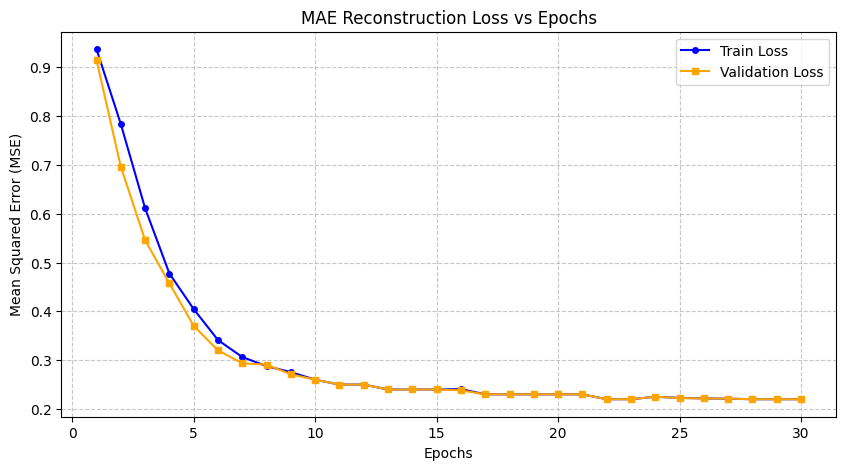


Calculating Average PSNR and SSIM on Validation Data...
   QUANTITATIVE EVALUATION RESULTS       
Total Samples Evaluated: 320
Average PSNR Score:      21.17 dB
Average SSIM Score:      0.5728


In [ ]:
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim
import torch

epochs = list(range(1, 31))

train_losses = [0.9370, 0.7838, 0.6114, 0.4775, 0.4047, 0.3412, 0.3064, 0.2878, 0.2755, 
                0.26, 0.25, 0.25, 0.24, 0.24, 0.24, 0.2407, 
                0.23, 0.23, 0.23, 0.23, 0.23, 0.22, 0.22, 0.2250, 0.2228, 0.2217, 0.2211, 0.22, 0.22, 0.22] 

val_losses = [0.9151, 0.6962, 0.5460, 0.4571, 0.3703, 0.3201, 0.2937, 0.2908, 0.2711, 
              0.26, 0.25, 0.25, 0.24, 0.24, 0.24, 0.2382,   
              0.23, 0.23, 0.23, 0.23, 0.23, 0.22, 0.22, 0.2250, 0.2224, 0.2215, 0.2213, 0.22, 0.22, 0.22]

if len(train_losses) == 30 and len(val_losses) == 30:
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, label='Train Loss', color='blue', marker='o', markersize=4)
    plt.plot(epochs, val_losses, label='Validation Loss', color='orange', marker='s', markersize=4)
    plt.title('MAE Reconstruction Loss vs Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print(f"Error: train_losses has {len(train_losses)} items and val_losses has {len(val_losses)} items. Both must be exactly 30.")

print("\nCalculating Average PSNR and SSIM on Validation Data...")
model.eval()

total_psnr = 0.0
total_ssim = 0.0
num_samples = 0
batches_to_test = 5 

with torch.no_grad():
    for batch_idx, (images, _) in enumerate(val_dataloader):
        if batch_idx >= batches_to_test:
            break
            
        images = images.to(device)
        with torch.amp.autocast('cuda'):
            if isinstance(model, torch.nn.DataParallel):
                _, pred, mask = model.module(images, mask_ratio=0.75)
            else:
                _, pred, mask = model(images, mask_ratio=0.75)
                
            pred_images = unpatchify_standalone(pred, patch_size=16)
        
        for i in range(images.size(0)):
            orig_img = denormalize(images[i]).cpu().permute(1, 2, 0).numpy()
            
            mask_visual = mask[i].reshape(14, 14).unsqueeze(-1).unsqueeze(-1).repeat(1, 1, 16, 16)
            mask_visual = mask_visual.reshape(224, 224).cpu().numpy()
            
            recon_img = denormalize(pred_images[i]).cpu().permute(1, 2, 0).numpy()
            final_recon = orig_img.copy()
            final_recon[mask_visual == 1] = recon_img[mask_visual == 1]
            
            total_psnr += compute_psnr(orig_img, final_recon, data_range=1.0)
            total_ssim += compute_ssim(orig_img, final_recon, data_range=1.0, channel_axis=-1)
            num_samples += 1

if num_samples > 0:
    avg_psnr = total_psnr / num_samples
    avg_ssim = total_ssim / num_samples

    print("=========================================")
    print("   QUANTITATIVE EVALUATION RESULTS       ")
    print("=========================================")
    print(f"Total Samples Evaluated: {num_samples}")
    print(f"Average PSNR Score:      {avg_psnr:.2f} dB")
    print(f"Average SSIM Score:      {avg_ssim:.4f}")
    print("=========================================")

Loading the Best Model for Visualization...


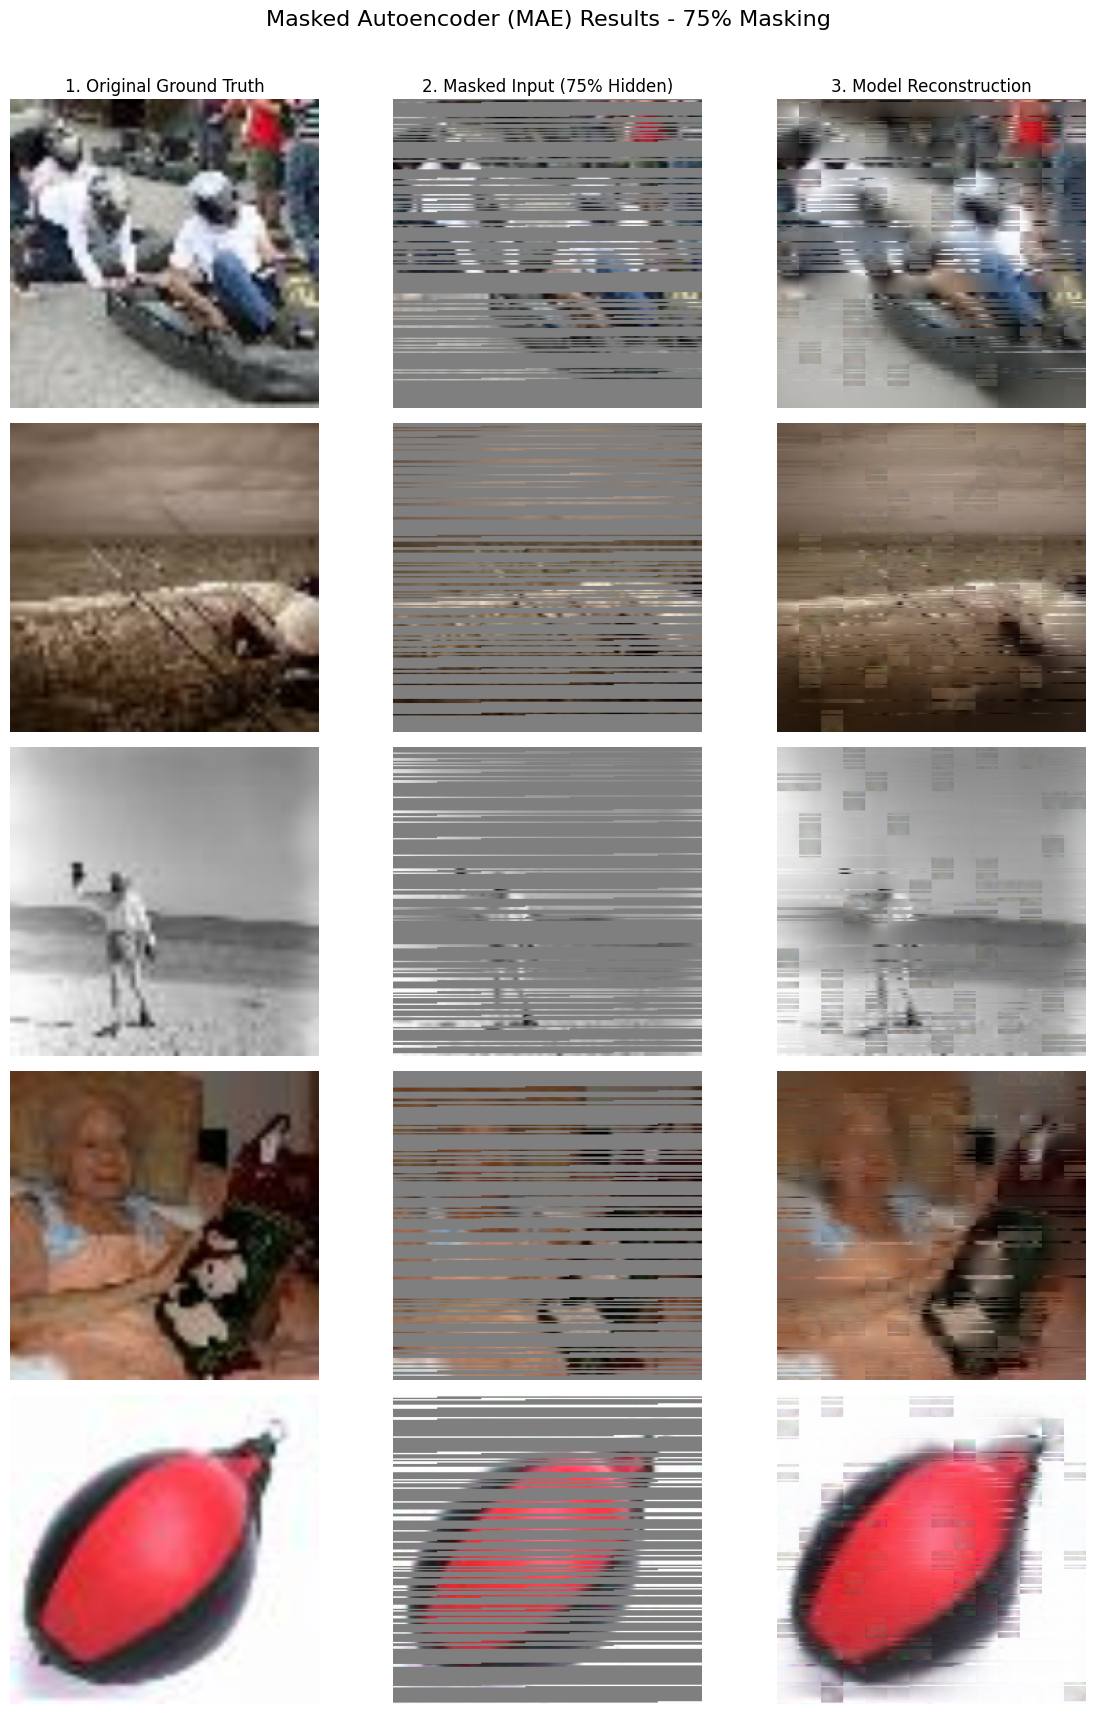

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np

print("Loading the Best Model for Visualization...")


best_checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(best_checkpoint['model_state_dict'])
model.eval()


def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(img_tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(img_tensor.device)
    img = img_tensor * std + mean
    return torch.clamp(img, 0, 1)


def unpatchify_standalone(pred, patch_size=16):
    p = patch_size
    h = w = int(np.sqrt(pred.shape[1])) 
    
   
    x = pred.reshape(shape=(pred.shape[0], h, w, p, p, 3))
    x = torch.einsum('nhwpqc->nchpwq', x)
    imgs = x.reshape(shape=(pred.shape[0], 3, h * p, h * p))
    return imgs


data_iter = iter(val_dataloader)
images, _ = next(data_iter)
images = images[:5].to(device)

with torch.no_grad():
    with torch.amp.autocast('cuda'):
        if isinstance(model, nn.DataParallel):
            loss, pred, mask = model.module(images, mask_ratio=0.75)
        else:
            loss, pred, mask = model(images, mask_ratio=0.75)
            
        pred_images = unpatchify_standalone(pred, patch_size=16)


fig, axes = plt.subplots(5, 3, figsize=(12, 18))
fig.suptitle('Masked Autoencoder (MAE) Results - 75% Masking', fontsize=16)

for i in range(5):

    orig_img = denormalize(images[i]).cpu().permute(1, 2, 0).numpy()
    axes[i, 0].imshow(orig_img)
    if i == 0: axes[i, 0].set_title("1. Original Ground Truth")
    axes[i, 0].axis('off')
    
  
    mask_visual = mask[i].reshape(14, 14).unsqueeze(-1).unsqueeze(-1).repeat(1, 1, 16, 16)
    mask_visual = mask_visual.reshape(224, 224).cpu()
    
    masked_img = denormalize(images[i]).cpu()
    masked_img[:, mask_visual == 1] = 0.5 
    masked_img = masked_img.permute(1, 2, 0).numpy()
    
    axes[i, 1].imshow(masked_img)
    if i == 0: axes[i, 1].set_title("2. Masked Input (75% Hidden)")
    axes[i, 1].axis('off')
    
   
    recon_img = denormalize(pred_images[i]).cpu()
    final_recon = denormalize(images[i]).cpu()
    
    
    final_recon[:, mask_visual == 1] = recon_img[:, mask_visual == 1]
    final_recon = final_recon.permute(1, 2, 0).numpy()
    
    axes[i, 2].imshow(final_recon)
    if i == 0: axes[i, 2].set_title("3. Model Reconstruction")
    axes[i, 2].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [ ]:
import os
from IPython.display import FileLink

os.chdir(r'/kaggle/working')

FileLink('mae_best_model.pth')

/kaggle/working/mae_best_model.pth